In [1]:
from get_stock_data import get_combined_tech_stocks
from get_normalized_price import get_normalized_prices
import numpy as np
import pandas as pd
from datetime import date, timedelta, datetime
import matplotlib.pyplot as plt
import seaborn as sns
from get_top_matches import get_top_matches
import pickle

In [2]:
tech_tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META"]
data = get_combined_tech_stocks(tech_tickers)

Fetching data from 2011-07-12 to 2026-07-08...


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


In [11]:
def get_history_and_target_price(target_ticker, window=50):
    target_price = get_normalized_prices(data, target_ticker, window)[:window]
    history_prices = {}
    for ticker in data.keys():
        history_prices[ticker] = get_normalized_prices(data, ticker, window)[window:]
    return target_price, history_prices

In [36]:
target_ticker = "GOOGL"
window = 100
dtw_window = 8
n_top_match = 30
blackout_window = int(window * 0.6)

In [37]:
target_price, historical_prices = get_history_and_target_price(target_ticker, window)

target = target_price[30]

In [38]:
top_matches = get_top_matches(target, historical_prices, window, dtw_window, n_top_match, blackout_window)

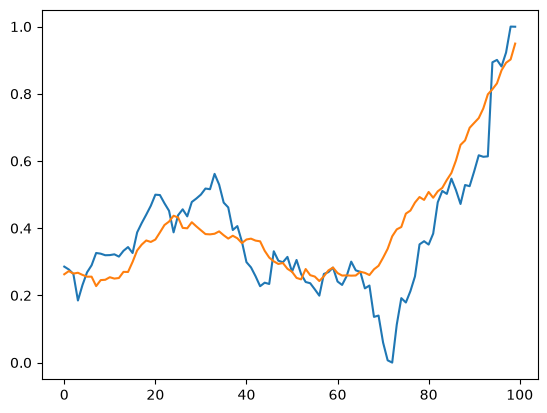

In [39]:
plt.plot(target[:window][::-1])

a = top_matches[0]["prices"]
for e in top_matches[1:]:
    a = [x + y for x, y in zip(a, e["prices"])]

a = [x / n_top_match for x in a]
plt.plot(a[::-1])


In [40]:
matches_with_futures = []
for e in top_matches:
    ticker = e["historical_ticker"]
    df = data[ticker]
    df["Date"] = pd.to_datetime(df["Date"])
    historical_dates_start = pd.to_datetime(e["historical_dates_start"])
    historical_dates_end = pd.to_datetime(e["historical_dates_end"])

    price = list(df.loc[(df["Date"] >= historical_dates_start) & (df["Date"] <= historical_dates_end + timedelta(days=30))]["Close"])

    price = np.array(price)

    normalized_price = (price - np.min(price[:window])) / (np.max(price[:window]) - np.min(price[:window]))

    normalized_price = normalized_price[::-1]

    matches_with_futures.append(normalized_price)

In [41]:
df = data[target_ticker]
df["Date"] = pd.to_datetime(df["Date"])
historical_dates_start = target[-2][1]
historical_dates_end = target[-2][0]

price = list(df.loc[(df["Date"] >= historical_dates_start) & (df["Date"] <= historical_dates_end + timedelta(days=30))]["Close"])

price = np.array(price)

normalized_price = (price - np.min(price[:window])) / (np.max(price[:window]) - np.min(price[:window]))

normalized_price = normalized_price[::-1]

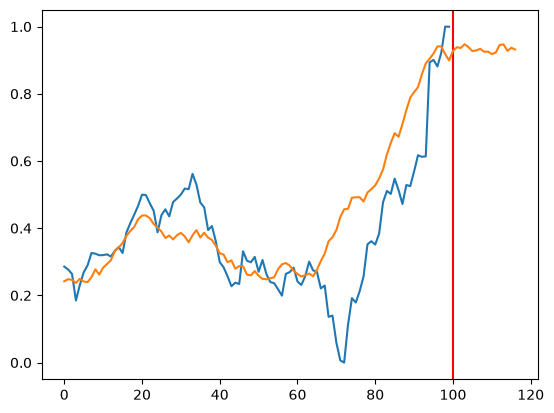

In [42]:
plt.plot(target[:window][::-1])

a = matches_with_futures[0]
for e in matches_with_futures[1:]:
    a = [x + y for x, y in zip(a, e)]

a = [x / n_top_match for x in a]
plt.axvline(x=window, color='red')

plt.plot(a[::-1])

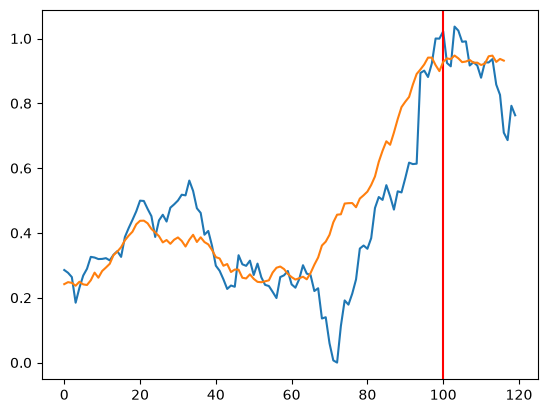

In [43]:
plt.plot(normalized_price[::-1])

a = matches_with_futures[0]
for e in matches_with_futures[1:]:
    a = [x + y for x, y in zip(a, e)]

a = [x / n_top_match for x in a]
plt.axvline(x=window, color='red')
plt.plot(a[::-1])